In [3]:
import ROOT as r
import fedrarootlogon 
from matplotlib import pyplot as plt
import matplotlib
import awkward as ak
import uproot
import numpy as np
import time

import sys
sys.path.insert(0, "/home/vincenzo/Documents/Vincenzo_FOOT/")
from Clustering_Cosmici_Frammenti import *

def g_func(x, p1, p2, p3):
    return p1* np.exp(- (x - p2)**2 / (2*p3**2) )

%jsroot on 
track_name = "b000333.2.0.0.trk.root"
file_name = "~/Scripts/GSI3/b33_vol.root"
file_name_cuts = "~/Scripts/GSI3/b33_vol_cuts.root"
brick_id = "GSI3"

k0_min = 3
k_stat = 1
VR0_max = 20000

Welcome to JupyROOT 6.26/06
Load FEDRA libs


# Taglio Cosmici

In [ ]:
file2 = r.TFile(file_name_cuts, "READ")

tracks_2 = file2.Get("tracks_cuts")

c = r.TCanvas()
tracks_2.Draw("VR0_av:tanf>>vr0_tan(100, 0,1, 100, 0, 20000)", "", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tan")
vr0_tan.SetTitle("VR0_av vs tan(#theta) [k_{0}>= "+ str(k0_min) + "]; tan(#theta); VR0_av")
vr0_tan.Draw("COLZ")
c.Draw()
r.gPad.Update()
st = vr0_tan.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
t1 = r.TText(c.GetUxmax()/15, 2000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

## Definizione Curve

In [ ]:
a2, b2 = 2500, 0.95  #2400, 0.95 x k0>=4
c2, d2 = 100, .45
c3, d3 = -100, .45
a3, b3 = 2300, 0.95
a1, b1 = 2900, 0.95
frag_cut2 = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - " + str(c2) + "*TMath::Exp(1/("+str(d2)+"*tan))"
frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"
nfrag_cut = "VR0_av < " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"
nfrag_cut2 = "VR0_av < " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - " + str(c2) + "*TMath::Exp(1/("+str(d2)+"*tan))"
nfrag_cut3 = "VR0_av < " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - (" + str(c3) + "*TMath::Exp(1/("+str(d3)+"*tan)))"

c = r.TCanvas()
tracks_2.Draw("VR0_av:tanf>>vr0_tan(100, 0,1, 100, 2000, 20000)", "", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tan")
vr0_tan.SetTitle("VR0_{av} vs tan(#theta) [k_{0}>="+str(k0_min)+"]; tan(#theta); VR0_{av}")
vr0_tan.Draw("COLZ")

N_tot = vr0_tan.GetEntries()

cut_curve3 = r.TF1("cut_med", str(a2)+"*(1 + exp("+str(b2)+ " *x*x)) - " + str(c2) + "*exp(1/" + str(d2) + "*x)", 0, 1)
cut_curve3.SetLineColor(8)
cut_curve3.SetLineWidth(3)
#cut_curve3.Draw("SAME")

cut_curve2 = r.TF1("cut_bk", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
cut_curve2.SetLineColor(8)
cut_curve2.SetLineWidth(3)
cut_curve2.Draw("SAME")

cut_curve21 = r.TF1("cut_21", str(a3)+"*(1 + exp("+str(b3)+ " *x*x))", 0, 1)
cut_curve21.SetLineColor(2)
cut_curve21.SetLineWidth(3)
cut_curve21.Draw("SAME")

cut_curve31 = r.TF1("cut_31", str(a1)+"*(1 + exp("+str(b1)+ " *x*x))", 0, 1)
cut_curve31.SetLineColor(95)
cut_curve31.SetLineWidth(3)
cut_curve31.Draw("SAME")


r.gPad.Update()
st = vr0_tan.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(c.GetUxmax()/15, 2500, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.SetLogz()
c.Draw()

In [ ]:
frag_cut_low = "VR0_av >= " + str(a3) + "*(1 + TMath::Exp(" + str(b3) + " *tan*tan))"
nfrag_cut_low = "VR0_av < " + str(a3) + "*(1 + TMath::Exp(" + str(b3) + " *tan*tan))"
frag_cut_high = "VR0_av >= " + str(a1) + "*(1 + TMath::Exp(" + str(b1) + " *tan*tan))"
nfrag_cut_high = "VR0_av < " + str(a1) + "*(1 + TMath::Exp(" + str(b1) + " *tan*tan))"

c = r.TCanvas()

tracks_2.Draw("tan>>low_cut", nfrag_cut_low)
h_low = r.gDirectory.Get("low_cut")
cosm_low = h_low.GetEntries()

tracks_2.Draw("tan>>low_cut", frag_cut_low)
h_low = r.gDirectory.Get("low_cut")
frag_low = h_low.GetEntries()

tracks_2.Draw("tan>>cut", nfrag_cut)
h_low = r.gDirectory.Get("cut")
cosm = h_low.GetEntries()

tracks_2.Draw("tan>>cut", frag_cut)
h_low = r.gDirectory.Get("cut")
frag = h_low.GetEntries()

tracks_2.Draw("tan>>high_cut", nfrag_cut_high)
h_low = r.gDirectory.Get("high_cut")
cosm_high = h_low.GetEntries()

tracks_2.Draw("tan>>high_cut", frag_cut_high)
h_low = r.gDirectory.Get("high_cut")
frag_high = h_low.GetEntries()

#c.Draw()

## Stima Errore Massimo (Max-Min)/2 [Cosmici]

In [ ]:
print(f" --- Taglio medio --- ")
print(f" #frag = {frag} ({100*round(frag/N_tot,3)} %), #cosm = {cosm} ( {100*round(cosm/N_tot, 3)} %) ")

print(f" --- Taglio basso --- ")
print(f" #frag = {frag_low} ({100*round(frag_low/N_tot,3)} %), #cosm = {cosm_low} ( {100*round(cosm_low/N_tot, 3)} %) ")

print(f" --- Taglio alto --- ")
print(f" #frag = {frag_high} ({100*round(frag_high/N_tot,3)} %), #cosm = {cosm_high} ( {100*round(cosm_high/N_tot, 3)} %) ")

In [ ]:
max_framm = max([frag, frag_low, frag_high])
low_framm = min([frag, frag_low, frag_high])

max_cosm = max([cosm, cosm_low, cosm_high])
low_cosm = min([cosm, cosm_low, cosm_high])

print(f" ERROR (Max-Min)/2")
print(f" Fragments: {(max_framm-low_framm)/2} ({100*round((max_framm-low_framm)/2/N_tot, 3)} %)")  
print(f" Cosmic Rays: {(max_cosm-low_cosm)/2} ({100*round((max_cosm-low_cosm)/2/N_tot, 3)} %)") 

## Stima Errore Massimo (Max-Min)/2 [VR1_av = 0]

In [ ]:
tracks_2.Draw("tan>>low_cut", frag_cut_low + " && VR1_av==0")
h_low = r.gDirectory.Get("low_cut")
Z1h_low = h_low.GetEntries()

tracks_2.Draw("tan>>cut", frag_cut + " && VR1_av==0")
h_low = r.gDirectory.Get("cut")
Z1h = h_low.GetEntries()

tracks_2.Draw("tan>>high_cut", frag_cut_high + " && VR1_av==0")
h_low = r.gDirectory.Get("high_cut")
Z1h_high = h_low.GetEntries()

In [ ]:
err = abs(Z1h_high-Z1h_low)/2
print(abs(Z1h_high-Z1h_low)/2)
print(err/Z1h)
print(N_tot)

In [ ]:
print(Z1h, Z1h_low, Z1h_high) 
print(Z1h/N_tot, Z1h_low/N_tot, Z1h_high/N_tot)

In [ ]:
tracks_2.Draw("tan>>low_cut", frag_cut_low + " && VR1_av>0 && VR1_av<7500")
h_low = r.gDirectory.Get("low_cut")
Z1h_low = h_low.GetEntries()

tracks_2.Draw("tan>>cut", frag_cut + " && VR1_av>0 && VR1_av<7500")
h_low = r.gDirectory.Get("cut")
Z1h = h_low.GetEntries()

tracks_2.Draw("tan>>high_cut", frag_cut_high + " && VR1_av>0 && VR1_av<7500")
h_low = r.gDirectory.Get("high_cut")
Z1h_high = h_low.GetEntries()
print(abs(Z1h_high-Z1h_low)/2)

In [ ]:
c = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>cut", frag_cut_high + " && VR1_av>0 && VR1_av<7500 && k2<2 && k3<2", "colz")
c.Draw()

Conclusione: il taglio VR0_av vs tan non influenza le popolazioni con VR1>0, quindi la stima dell'errore si ferma alla componente Z=1 ad alta energia con i tagli netti.

# Stima Errore VP123

In [4]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_123.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR1_av, track.VR2_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [5]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR1_av, track.VR2_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123, vr123b = [], []
for i in vr123s:
    vr123.append(i[0])
    vr123b.append(i[1])
    
file_pca.Close()

In [6]:
file_pca_2 = r.TFile("PCA2.root", "RECREATE")

pca_1 = r.TNtuple("pca_1", "", "VR123:VR123b")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i], vr123b[i])

In [7]:
kn = r.TCanvas()
pca_1.Draw("VR123>>123(100, -10, 5.5)")

hi = r.gDirectory.Get("123")
hi.SetTitle("VP_{123} [Frag_Cut & k_{1}>0 & k_{2,3}>1]; VP_{123}; Entries")
hi.Draw("")

t1 = r.TText(-6., 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

kn.Draw()

In [8]:
pca_1.Write("pca_123")

453

In [9]:
file_pca = r.TFile("PCA_123.root", "READ")
info_pca = file_pca.Get("pca")
info_pca.AddFriend(pca_1)

## Fit Scelto

In [27]:
r.Math.MinimizerOptions.SetDefaultTolerance(1e-10)
print(min(vr123))
print(max(vr123))

-10.653230379483716
1.553927916526126


In [41]:
c = r.TCanvas()
info_pca.Draw("VR123>>histo123(100, -12, 3.)", "", "colz")

h123 = r.gDirectory.Get("histo123")
h123.SetTitle("VP_{123} (Frag_Cut, k_{1}>0, k_{2}, k_{3}>1);VP_{123};Entries")

r.gStyle.SetOptStat(0)
g1 = r.TF1("g1", "gaus(0) + gaus(3) + gaus(6) + gaus(9) + gaus(12) + gaus(15)", -12.5, 2.)
g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
g1.SetParameter(11, 0.2)
g1.SetParameter(12, 80)
g1.SetParameter(13, -0.35)
g1.SetParameter(14, 0.5)
g1.SetParameter(15, 2500)
g1.SetParameter(16, .5)
g1.SetParameter(17, 0.8)
#g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
g1.SetLineWidth(2)

h123.Fit("g1", "L","", -12, 2.)
#c.Update()
h123.Draw("PE")

params = g1.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) 
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)  #r.kCyan+2
comp1.SetLineStyle(2)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=5
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineStyle(2)
comp2.SetLineColor(95) #r.kGreen+2
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #shoulder
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(8)  #r.kOrange
comp3.SetLineStyle(2)
comp3.Draw("SAME")

comp4 = r.TF1("comp4", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=2
comp4.SetParameters(params[9], params[10], params[11])
comp4.SetLineColor(r.kPink+3)
comp4.SetLineStyle(2)
comp4.Draw("SAME")

comp5 = r.TF1("comp5", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=3
comp5.SetParameters(params[12], params[13], params[14])
comp5.SetLineColor(r.kMagenta)
comp5.SetLineWidth(2)
comp5.Draw("SAME")

comp6 = r.TF1("comp6", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=4
comp6.SetParameters(params[15], params[16], params[17])
comp6.SetLineColor(r.kCyan+2)
comp6.SetLineStyle(2)
comp6.Draw("SAME")

comps = [comp1, comp2, comp3, comp4, comp5, comp6]
for comp in comps:
    comp.SetLineStyle(9)

legend = r.TLegend(0.4,0.65,0.68,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry("fit", "#splitline{Prob = " + str(round(g1.GetProb(),2))  +"}{#chi^{2}/NDF =" + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF())  +"}" )
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z = 4")
legend.AddEntry(comp4, "Z = 5")
legend.AddEntry(comp5, "Z >=6")
legend.AddEntry(comp6, "Z >=6")
legend.Draw("SAME")

legend2 = r.TLegend(0.15,0.7,0.4,0.85)
legend2.SetTextFont(0)
legend2.SetTextSize(0.04)
legend2.AddEntry("Entries", str("Entries = "+str(hi.GetEntries())), "" )
legend2.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF()), "" )
legend2.AddEntry("prob", "Prob = " + str(round(g1.GetProb(), 3)), "")
legend2.Draw("SAME")

g1.Draw("SAME")

c.SetLogy(1)

c.Draw()

 FCN=50.0617 FROM MIGRAD    STATUS=FAILED       1907 CALLS        1908 TOTAL
                     EDM=1.87274e-12    STRATEGY= 1      ERR MATRIX APPROXIMATE
  EXT PARAMETER                APPROXIMATE        STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           1.78220e+01   1.70935e+00   6.75384e-03   4.06646e-07
   2  p1          -9.07747e+00   5.74241e-02   2.40166e-04   4.12940e-06
   3  p2           5.88531e-01   4.40555e-02   1.50039e-04   1.22300e-05
   4  p3           4.47663e+01   2.90091e+00   1.06493e-02   1.96247e-07
   5  p4          -6.55676e+00   3.22091e-02   1.47234e-04   3.59533e-06
   6  p5           5.81725e-01   3.09897e-02   9.72656e-05   3.12571e-05
   7  p6           3.15891e+01   2.85916e+00   1.01779e-02   2.66578e-07
   8  p7          -3.43795e+00   3.34938e-02   1.56846e-04   1.13255e-08
   9  p8           4.50523e-01   3.50809e-02   1.09023e-04   3.18424e-05
  10  p9           6.37916e+01   4.55855e+

Warning in <Fit>: Abnormal termination of minimization.


## Ripetizione N Volte

In [42]:
def make_classification_123_ALL2(PCA_tup, fit_func, file_name, tupname, N_gaus=6, Z0=2, Z1=3, Z2=4, Z3=5, Z4=6): 
    
    params = fit_func.GetParameters()
    file_pca2 = r.TFile(file_name, "RECREATE")
    low_value, high_value = 0., 0.
    
    pca_2 = r.TNtuple(tupname, "", "VR123:Z_c:VR123b")

    Z_c = 0.
    Z_s = []
    z0, z1, z2, z3, z4 = 0, 0, 0, 0, 0
    cn_s = []
    for i in range(N_gaus+1):
        cn_s.append([])
        
    for track in PCA_tup:
        PCA_value = track.VR123
        PCA_value2 = track.VR123b  
        random_number = np.random.uniform(0,1)
        probs = []
        for i in range(N_gaus):
            probs.append(g_func(PCA_value, params[0+int(3*i)], params[1+int(3*i)], params[2+int(3*i)])/fit_func.Eval(PCA_value) )
        o_ps = sorted(probs)
        indexes = []
        for p in probs:
            indexes.append(o_ps.index(p))
        
        if (random_number <= o_ps[0]):
            check = True
            pos = 0
            for j1 in range(len(indexes)):
                if (indexes[j1] == 0): 
                    pos = j1
            for j2 in range(len(indexes)):
                if (j2 != pos and indexes[j2] == 0):
                    check = False
            if (check):
                cn_s[pos].append(PCA_value)
                if (pos == 0):
                    Z_c = Z1
                    z1 = z1 +1
                elif (pos == 2):
                    Z_c = Z2
                    z2 = z2 +1
                elif (pos == 0):
                    Z_c = Z0
                    z0 = z0 +1
                elif(pos == 3):
                    Z_c = Z3
                    z3 = z3 +1
                else:
                    Z_c = Z4
                    z4 = z4 +1
                
                
        for k in range(N_gaus-1):
            
            if (k == 0):
                low_value = o_ps[0]
            elif (k == 1):
                low_value = o_ps[0] + o_ps[k]
            elif (k == 2):
                low_value = high_value
            high_value = low_value + o_ps[k+1]
        
            if (k < N_gaus-2):
                if (random_number > low_value and random_number <= high_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 1):
                            Z_c = Z1
                            z1 = z1 +1
                        elif (pos == 2):
                            Z_c = Z2
                            z2 = z2 +1
                        elif (pos == 0):
                            Z_c = Z0
                            z0 = z0 +1
                        elif(pos == 3):
                            Z_c = Z3
                            z3 = z3+1
                        else:
                            Z_c = Z4
                            z4 = z4+1
            elif (k == N_gaus-2):  #funziona per N_gaus = 4
                if (random_number > low_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 1):
                            Z_c = Z1
                            z1 = z1+1
                        elif (pos == 2):
                            Z_c = Z2
                            z2 = z2+1
                        elif (pos == 0):
                            Z_c = Z0
                            z0 = z0+1
                        elif(pos == 3):
                            Z_c = Z3
                            z3 = z3+1
                        else:
                            Z_c = Z4
                            z4 = z4+1
        Z_s.append(Z_c)
        pca_2.Fill(PCA_value, Z_c)     
    pca_2.Write(tupname)
    file_pca2.Close()
    return cn_s, Z_s

### Minimizer Genetico

In [43]:
gen = 0
if (gen == 1):
    r.Math.MinimizerOptions.SetDefaultMinimizer("Genetic")
    r.Math.MinimizerOptions.SetDefaultTolerance(1e-8)
    r.Math.MinimizerOptions.SetDefaultMaxIterations(200)

    g1.SetParLimits(0, 5, 40)
    g1.SetParLimits(1, -9., -7.)
    g1.SetParLimits(2, 0.1, 1.)

    g1.SetParLimits(3, 20, 60)
    g1.SetParLimits(4, -7., -5.)
    g1.SetParLimits(5, 0.1, 1.)

    g1.SetParLimits(6, 10, 50)
    g1.SetParLimits(7, -4., -2.)
    g1.SetParLimits(8, 0.1, 1.)

    g1.SetParLimits(9, 40, 80)
    g1.SetParLimits(10, -2., -.1)
    g1.SetParLimits(11, 0.1, 1.)

    g1.SetParLimits(12, 200, 400)
    g1.SetParLimits(13, -0.2, 0.4)
    g1.SetParLimits(14, 0.1, 1.)

    g1.SetParLimits(15, 2000, 3000)
    g1.SetParLimits(16, 0., 1.)
    g1.SetParLimits(17, 0.1, 1.)

In [44]:
if (gen == 1):
    t1 = time.time()

    N = 20
    x = np.linspace(min(vr123), max(vr123), 1000)
    probs = []

    for i in range(N):
        h123.Fit(g1, "L", "", -10.5, 2)
        params = g1.GetParameters()
        plt.plot(x, g_func(x, params[0], params[1], params[2]), color = 'turquoise')
        plt.plot(x, g_func(x, params[3], params[4], params[5]), color = 'yellow')
        plt.plot(x, g_func(x, params[6], params[7], params[8]), color = 'b')
        plt.plot(x, g_func(x, params[9], params[10], params[11]), color = 'r')
        plt.plot(x, g_func(x, params[12], params[13], params[14]), color = 'orange')
        plt.plot(x, g_func(x, params[15], params[16], params[17]), color = 'g')
        probs.append(g1.GetProb())
    t2 = time.time()
    print(t2-t1)
#plt.yscale('log')
    plt.show()
    print(probs)

### Fix Parametro (Binning 1)

In [45]:
N1 = 1000
N_gaus = 6

n_class = []
means, std_devs, peaks = [], [], []
for i in range(N_gaus):
    means.append(np.random.normal(params[1 + i*3], 2*g1.GetParError(1 + i*3), N1))
    std_devs.append(np.random.normal(params[2 + i*3], 2*g1.GetParError(2 + i*3), N1))
    peaks.append(np.random.normal(params[0 + i*3], 2*g1.GetParError(0 + i*3), N1))
    n_class.append([])

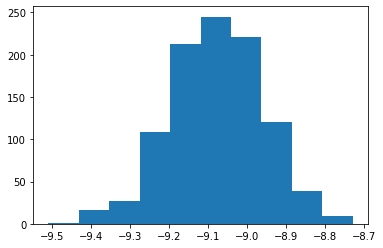

In [46]:
plt.hist(means[0])
plt.show()

 Fit # 0
 Fit # 20
 Fit # 40
 Fit # 60
 Fit # 80
 Fit # 100
 Fit # 120
 Fit # 140
 Fit # 160
 Fit # 180
4.668057203292847


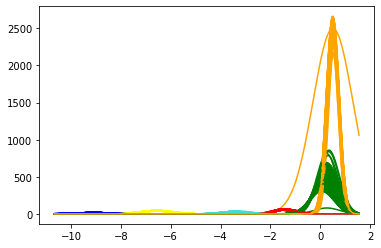

 FCN=91.057 FROM MIGRAD    STATUS=CONVERGED     702 CALLS         703 TOTAL
                     EDM=1.99883e-14    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   0.8 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           1.73880e+01   1.69231e+00  -0.00000e+00  -2.63595e-08
   2  p1          -9.01637e+00     fixed    
   3  p2           6.17962e-01   4.73238e-02   0.00000e+00  -1.93305e-06
   4  p3           4.52028e+01   2.87740e+00  -0.00000e+00  -6.69796e-10
   5  p4          -6.54694e+00     fixed    
   6  p5           5.71007e-01   2.76495e-02   0.00000e+00  -2.07929e-06
   7  p6           3.20722e+01   2.84992e+00   0.00000e+00  -1.01214e-08
   8  p7          -3.45214e+00     fixed    
   9  p8           4.39469e-01   3.17577e-02  -0.00000e+00   2.71670e-08
  10  p9           6.40736e+01   4.22965e+00  -0.00000e+00   4.39688e-08
  11  p10         -1.49026e+00     fixed 

Warning in <Fit>: Abnormal termination of minimization.


In [47]:
from collections import Counter
N2 = 200
probs = []
x = np.linspace(min(vr123), max(vr123), 1000)
t1 = time.time()
good_fits = 0
file_name123 = '123.root'
tup_name123 = '123_c'
p0, p1, p2, p3, p4, p5 = [], [], [], [], [], []
p6, p7, p8, p9, p10, p11 = [], [], [], [], [], []
p12, p13, p14, p15, p16, p17 = [], [], [], [], [], []
prova = []
zs = []

for i in range(N2):
    g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
    g1.SetParameter(11, 0.2)
    g1.SetParameter(12, 80)
    g1.SetParameter(13, -0.35)
    g1.SetParameter(14, 0.5)
    g1.SetParameter(15, 2500)
    g1.SetParameter(16, .5)
    g1.SetParameter(17, 0.8)
    
    # Fix Means
    g1.FixParameter(1, means[0][i])
    g1.FixParameter(4, means[1][i])
    g1.FixParameter(7, means[2][i])
    g1.FixParameter(10, means[3][i])
    g1.FixParameter(13, means[4][i])
    g1.FixParameter(16, means[5][i])
    
    
    h123.Fit("g1", "L", "", -10.5, 2)
    params2 = g1.GetParameters()
    plt.plot(x, g_func(x, params2[0], params2[1], params2[2]), color = 'b')
    plt.plot(x, g_func(x, params2[3], params2[4], params2[5]), color = 'yellow')
    plt.plot(x, g_func(x, params2[6], params2[7], params2[8]), color = 'turquoise')
    plt.plot(x, g_func(x, params2[9], params2[10], params2[11]), color = 'r')
    plt.plot(x, g_func(x, params2[12], params2[13], params2[14]), color = 'g')
    plt.plot(x, g_func(x, params2[15], params2[16], params2[17]), color = 'orange')
    probs.append(g1.GetProb())
    if (g1.GetProb()>=0.001):
        good_fits = good_fits + 1
        zs.append([])
        prova, zs[-1] = make_classification_123_ALL2(info_pca, g1, file_name123, tup_name123, 6, 2, 3, 4, 5, 6)
        
        p0.append(params2[0])
        p1.append(params2[1])
        p2.append(params2[2])
        p3.append(params2[3])
        p4.append(params2[4])
        p5.append(params2[5])
        p6.append(params2[6])
        p7.append(params2[7])
        p8.append(params2[8])
        p9.append(params2[9])
        p10.append(params2[10])
        p11.append(params2[11])
        p12.append(params2[12])
        p13.append(params2[13])
        p14.append(params2[14])
        p15.append(params2[15])
        p16.append(params2[16])
        p17.append(params2[17])
        
    if (i%int(N2/10)==0):
        print(" Fit # " + str(i))
    if (good_fits == 100):
        break
    
t2 = time.time()
print(t2-t1)
    
plt.show()

In [48]:
s = 0
for el in prova:
    s = s + len(el)
print(s)

17677


In [49]:
print(good_fits)
print(h123.GetEntries())

2
14914.0


In [50]:
z2, z3, z4, z5, z6 = [], [], [], [], []
for counts in zs:
    z2.append(counts.count(2))
    z3.append(counts.count(3))
    z4.append(counts.count(4))
    z5.append(counts.count(5))
    z6.append(counts.count(6))

for el in [z2, z3, z4, z5, z6]:
    print(f" Mean: {np.mean(el)}, Standard Dev: {np.std(el)}")
    print("")

 Mean: 174.0, Standard Dev: 2.0

 Mean: 436.5, Standard Dev: 2.5

 Mean: 235.5, Standard Dev: 0.5

 Mean: 375.0, Standard Dev: 3.0

 Mean: 13693.0, Standard Dev: 3.0



In [51]:
for el in [z2, z3, z4, z5, z6]:
    print(f" Mean: {np.mean(el)}, Standard Dev: {np.std(el)}")
    print("")

 Mean: 174.0, Standard Dev: 2.0

 Mean: 436.5, Standard Dev: 2.5

 Mean: 235.5, Standard Dev: 0.5

 Mean: 375.0, Standard Dev: 3.0

 Mean: 13693.0, Standard Dev: 3.0



In [52]:
c = r.TCanvas()
med1 = r.TF1("med1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
med2 = r.TF1("med2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
med1.SetLineColor(4)
x = np.linspace(-10.5, 4, 1000)
gr = r.TGraph()
npoint = 0
for i in range(len(p0)):
    med1.SetParameters(p0[i], p1[i], p2[i])
    for xpos in x:
        y_pos = med1.Eval(xpos)
        gr.SetPoint(npoint,xpos,y_pos)
        npoint = npoint + 1
gr2 = r.TGraph()      
for i in range(len(p0)):
    med2.SetParameters(p3[i], p4[i], p5[i])
    for xpos in x:
        y_pos = med2.Eval(xpos)
        gr2.SetPoint(npoint,xpos,y_pos)
        npoint = npoint + 1
        
gr3 = r.TGraph()      
for i in range(len(p0)):
    med2.SetParameters(p6[i], p7[i], p8[i])
    for xpos in x:
        y_pos = med2.Eval(xpos)
        gr3.SetPoint(npoint,xpos,y_pos)
        npoint = npoint + 1
        
gr4 = r.TGraph()      
for i in range(len(p0)):
    med2.SetParameters(p9[i], p10[i], p11[i])
    for xpos in x:
        y_pos = med2.Eval(xpos)
        gr4.SetPoint(npoint,xpos,y_pos)
        npoint = npoint + 1
        
gr5 = r.TGraph()      
for i in range(len(p0)):
    med2.SetParameters(p12[i], p13[i], p14[i])
    for xpos in x:
        y_pos = med2.Eval(xpos)
        gr5.SetPoint(npoint,xpos,y_pos)
        npoint = npoint + 1
        
gr6 = r.TGraph()      
for i in range(len(p0)):
    med2.SetParameters(p15[i], p16[i], p17[i])
    for xpos in x:
        y_pos = med2.Eval(xpos)
        gr6.SetPoint(npoint,xpos,y_pos)
        npoint = npoint + 1
        
h123.Draw("PE")
#gr.SetFillColor(r.kOrange)
#gr.SetFillStyle(2)

gr.SetMarkerColor(4)
gr2.SetMarkerColor(95)
gr3.SetMarkerColor(8)
gr4.SetMarkerColor(r.kPink+3)
gr5.SetMarkerColor(r.kMagenta)
gr6.SetMarkerColor(r.kCyan+2)

gr.Draw("SAME")
gr2.Draw("SAME")
gr3.Draw("SAME")
gr4.Draw("SAME")
gr5.Draw("SAME")
gr6.Draw("SAME")
c.SetLogy(1)

legend = r.TLegend(0.4,0.65,0.68,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry("fit", "#splitline{Prob = " + str(round(g1.GetProb(),2))  +"}{#chi^{2}/NDF =" + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF())  +"}" )
legend.AddEntry(comp6, "Z = 2")
legend.AddEntry(comp3, "Z = 3")
legend.AddEntry(comp2, "Z = 4")
legend.AddEntry(comp4, "Z = 5")
legend.AddEntry(comp5, "Z >=6")
legend.AddEntry(comp1, "Z >=6")
legend.Draw("SAME")

legend2 = r.TLegend(0.15,0.7,0.4,0.85)
legend2.SetTextFont(0)
legend2.SetTextSize(0.04)
legend2.AddEntry("Entries", f"Entries = {hi.GetEntries()}", "" )
legend2.AddEntry("Nf", "# Fits = 200", "")
#legend2.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF()), "" )
#legend2.AddEntry("prob", "Prob = " + str(round(g1.GetProb(), 4)), "")
legend2.Draw("SAME")

c.Draw()

## Fit Binning 2 (VP123)

In [53]:
c = r.TCanvas()
info_pca.Draw("VR123>>histo123(115)", "", "colz")

h123 = r.gDirectory.Get("histo123")
h123.SetTitle("VP_{123} (Frag_Cut, k_{1}>0, k_{2}, k_{3}>1);VP_{123};Entries")

r.gStyle.SetOptStat(0)
g1 = r.TF1("g1", "gaus(0) + gaus(3) + gaus(6) + gaus(9) + gaus(12) + gaus(15)", -10.5, 2.)
g1.SetParameters(20, -8., .5, 50, -6., 0.5, 40, -3.2, 0.5, 70, -2.)
g1.SetParameter(11, 0.2)
g1.SetParameter(12, 80)
g1.SetParameter(13, -0.35)
g1.SetParameter(14, 0.5)
g1.SetParameter(15, 2500)
g1.SetParameter(16, .5)
g1.SetParameter(17, 0.8)
#g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
g1.SetLineWidth(2)

h123.Fit("g1", "L","", -10.5, 2.)
#c.Update()
h123.Draw("PE")

params = g1.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) 
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(r.kCyan+2)
comp1.SetLineStyle(2)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=5
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineStyle(2)
comp2.SetLineColor(r.kGreen+2)
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #shoulder
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(r.kOrange)
comp3.SetLineStyle(2)
comp3.Draw("SAME")

comp4 = r.TF1("comp4", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=2
comp4.SetParameters(params[9], params[10], params[11])
comp4.SetLineColor(r.kPink+3)
comp4.SetLineStyle(2)
comp4.Draw("SAME")

comp5 = r.TF1("comp5", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=3
comp5.SetParameters(params[12], params[13], params[14])
comp5.SetLineColor(r.kMagenta)
comp5.SetLineWidth(2)
comp5.Draw("SAME")

comp6 = r.TF1("comp6", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=4
comp6.SetParameters(params[15], params[16], params[17])
comp6.SetLineColor(4)
comp6.SetLineStyle(2)
comp6.Draw("SAME")

comps = [comp1, comp2, comp3, comp4, comp5, comp6]
for comp in comps:
    comp.SetLineStyle(9)

legend = r.TLegend(0.4,0.65,0.68,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry("fit", "#splitline{Prob = " + str(round(g1.GetProb(),2))  +"}{#chi^{2}/NDF =" + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF())  +"}" )
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z = 4")
legend.AddEntry(comp4, "Z = 5")
legend.AddEntry(comp5, "Z >=6")
legend.AddEntry(comp6, "Z >=6")
legend.Draw("SAME")

legend2 = r.TLegend(0.15,0.7,0.4,0.85)
legend2.SetTextFont(0)
legend2.SetTextSize(0.04)
legend2.AddEntry("Entries", f"Entries = {hi.GetEntries()}", "" )
legend2.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF()), "" )
legend2.AddEntry("prob", "Prob = " + str(round(g1.GetProb(), 4)), "")
legend2.Draw("SAME")

g1.Draw("SAME")

c.SetLogy(1)

c.Draw()

 FCN=56.8444 FROM MIGRAD    STATUS=CONVERGED    1433 CALLS        1434 TOTAL
                     EDM=8.2921e-13    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   1.0 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           1.48284e+01   1.47930e+00  -0.00000e+00   2.68440e-09
   2  p1          -9.07962e+00   5.80434e-02   0.00000e+00  -9.49583e-06
   3  p2           5.93078e-01   5.21221e-02   0.00000e+00  -3.09371e-06
   4  p3           3.79014e+01   2.47275e+00  -0.00000e+00   4.30910e-08
   5  p4          -6.55692e+00   3.20072e-02  -0.00000e+00   3.76433e-06
   6  p5           5.71700e-01   3.13767e-02   0.00000e+00  -1.88236e-05
   7  p6           2.59269e+01   2.32884e+00  -0.00000e+00   1.07618e-07
   8  p7          -3.43962e+00   3.41010e-02   0.00000e+00  -1.04987e-06
   9  p8           4.61295e-01   3.59744e-02   0.00000e+00  -4.82479e-06
  10  p9           5.39193e+01

In [54]:
N1 = 1000
N_gaus = 6

n_class = []
means, std_devs, peaks = [], [], []
for i in range(N_gaus):
    means.append(np.random.normal(params[1 + i*3], 2*g1.GetParError(1 + i*3), N1))
    std_devs.append(np.random.normal(params[2 + i*3], 2*g1.GetParError(2 + i*3), N1))
    peaks.append(np.random.normal(params[0 + i*3], 2*g1.GetParError(0 + i*3), N1))
    n_class.append([])

 Fit # 0
 Fit # 20
 Fit # 40
 Fit # 60
 Fit # 80
156.7775797843933


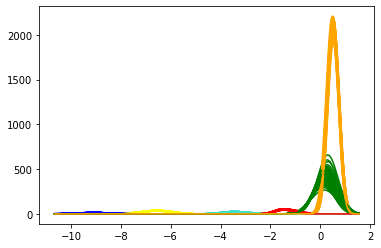

 FCN=83.4529 FROM MIGRAD    STATUS=CONVERGED     649 CALLS         650 TOTAL
                     EDM=6.0979e-13    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   0.5 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           1.48626e+01   1.42381e+00  -0.00000e+00   2.92883e-08
   2  p1          -9.03529e+00     fixed    
   3  p2           5.86257e-01   4.28063e-02   0.00000e+00  -3.10792e-06
   4  p3           3.76110e+01   2.39939e+00  -0.00000e+00  -2.53947e-08
   5  p4          -6.61500e+00     fixed    
   6  p5           5.77440e-01   2.83987e-02   0.00000e+00  -6.39410e-06
   7  p6           2.49177e+01   2.21627e+00   0.00000e+00  -3.23179e-07
   8  p7          -3.35761e+00     fixed    
   9  p8           4.88118e-01   3.71725e-02   0.00000e+00  -1.78256e-05
  10  p9           5.59428e+01   3.92213e+00   0.00000e+00  -1.94708e-07
  11  p10         -1.48034e+00     fixed 

Warning in <Fit>: Abnormal termination of minimization.


In [59]:
from collections import Counter
N2 = 200
probs = []
x = np.linspace(min(vr123), max(vr123), 1000)
t1 = time.time()
good_fits = 0
file_name123 = '123.root'
tup_name123 = '123_c'
p0, p1, p2, p3, p4, p5 = [], [], [], [], [], []
p6, p7, p8, p9, p10, p11 = [], [], [], [], [], []
p12, p13, p14, p15, p16, p17 = [], [], [], [], [], []
prova = []
zs = []

for i in range(N2):
    g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
    g1.SetParameter(11, 0.2)
    g1.SetParameter(12, 80)
    g1.SetParameter(13, -0.35)
    g1.SetParameter(14, 0.5)
    g1.SetParameter(15, 2500)
    g1.SetParameter(16, .5)
    g1.SetParameter(17, 0.8)
    
    # Fix Means
    g1.FixParameter(1, means[0][i])
    g1.FixParameter(4, means[1][i])
    g1.FixParameter(7, means[2][i])
    g1.FixParameter(10, means[3][i])
    g1.FixParameter(13, means[4][i])
    g1.FixParameter(16, means[5][i])
    
    
    h123.Fit("g1", "L", "", -10.5, 2)
    params2 = g1.GetParameters()
    plt.plot(x, g_func(x, params2[0], params2[1], params2[2]), color = 'b')
    plt.plot(x, g_func(x, params2[3], params2[4], params2[5]), color = 'yellow')
    plt.plot(x, g_func(x, params2[6], params2[7], params2[8]), color = 'turquoise')
    plt.plot(x, g_func(x, params2[9], params2[10], params2[11]), color = 'r')
    plt.plot(x, g_func(x, params2[12], params2[13], params2[14]), color = 'g')
    plt.plot(x, g_func(x, params2[15], params2[16], params2[17]), color = 'orange')
    probs.append(g1.GetProb())
    if (g1.GetProb()>=0.):
        good_fits = good_fits + 1
        zs.append([])
        prova, zs[-1] = make_classification_123_ALL2(info_pca, g1, file_name123, tup_name123, 6, 2, 3, 4, 5, 6)
        
        p0.append(params2[0])
        p1.append(params2[1])
        p2.append(params2[2])
        p3.append(params2[3])
        p4.append(params2[4])
        p5.append(params2[5])
        p6.append(params2[6])
        p7.append(params2[7])
        p8.append(params2[8])
        p9.append(params2[9])
        p10.append(params2[10])
        p11.append(params2[11])
        p12.append(params2[12])
        p13.append(params2[13])
        p14.append(params2[14])
        p15.append(params2[15])
        p16.append(params2[16])
        p17.append(params2[17])
        
    if (i%int(N2/10)==0):
        print(" Fit # " + str(i))
    if (good_fits == 100):
        break
    
t2 = time.time()
print(t2-t1)
    
plt.show()

In [61]:
print(good_fits)

100


In [62]:
z2, z3, z4, z5, z6 = [], [], [], [], []
for counts in zs:
    z2.append(counts.count(2))
    z3.append(counts.count(3))
    z4.append(counts.count(4))
    z5.append(counts.count(5))
    z6.append(counts.count(6))

for el in [z2, z3, z4, z5, z6]:
    print(f" Mean: {np.mean(el)}, Standard Dev: {np.std(el)}")
    print("")

 Mean: 176.01, Standard Dev: 6.644539111179946

 Mean: 433.82, Standard Dev: 7.265507552814188

 Mean: 238.03, Standard Dev: 4.208218150238887

 Mean: 373.92, Standard Dev: 18.784930130293272

 Mean: 13692.22, Standard Dev: 17.3508385964483



In [58]:
n_class2 = n_class

## Fit Binning 3

In [ ]:
c = r.TCanvas()
info_pca.Draw("VR123>>histo123(90)", "", "colz")

h123 = r.gDirectory.Get("histo123")
h123.SetTitle("VP_{123} (Frag_Cut, k_{1}>0, k_{2}, k_{3}>1);VP_{123};Entries")

r.gStyle.SetOptStat(0)
g1 = r.TF1("g1", "gaus(0) + gaus(3) + gaus(6) + gaus(9) + gaus(12) + gaus(15)", -10.5, 2.)
g1.SetParameters(20, -8., .5, 50, -6., 0.5, 40, -3.2, 0.5, 70, -2.)
g1.SetParameter(11, 0.2)
g1.SetParameter(12, 80)
g1.SetParameter(13, -0.35)
g1.SetParameter(14, 0.5)
g1.SetParameter(15, 2500)
g1.SetParameter(16, .5)
g1.SetParameter(17, 0.8)
#g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
g1.SetLineWidth(2)

h123.Fit("g1", "L","", -10.5, 2.)
#c.Update()
h123.Draw("PE")

params = g1.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) 
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(r.kCyan+2)
comp1.SetLineStyle(2)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=5
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineStyle(2)
comp2.SetLineColor(r.kGreen+2)
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #shoulder
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(r.kOrange)
comp3.SetLineStyle(2)
comp3.Draw("SAME")

comp4 = r.TF1("comp4", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=2
comp4.SetParameters(params[9], params[10], params[11])
comp4.SetLineColor(r.kPink+3)
comp4.SetLineStyle(2)
comp4.Draw("SAME")

comp5 = r.TF1("comp5", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=3
comp5.SetParameters(params[12], params[13], params[14])
comp5.SetLineColor(r.kMagenta)
comp5.SetLineWidth(2)
comp5.Draw("SAME")

comp6 = r.TF1("comp6", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=4
comp6.SetParameters(params[15], params[16], params[17])
comp6.SetLineColor(4)
comp6.SetLineStyle(2)
comp6.Draw("SAME")

comps = [comp1, comp2, comp3, comp4, comp5, comp6]
for comp in comps:
    comp.SetLineStyle(9)

legend = r.TLegend(0.4,0.65,0.68,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry("fit", "#splitline{Prob = " + str(round(g1.GetProb(),2))  +"}{#chi^{2}/NDF =" + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF())  +"}" )
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z = 4")
legend.AddEntry(comp4, "Z = 5")
legend.AddEntry(comp5, "Z >=6")
legend.AddEntry(comp6, "Z >=6")
legend.Draw("SAME")

legend2 = r.TLegend(0.4,0.65,0.68,0.85)
legend2.SetTextFont(0)
legend2.SetTextSize(0.04)
legend2.AddEntry("fit", "#splitline{Prob = " + str(round(g1.GetProb(),5))  +"}{#chi^{2}/NDF =" + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF())  +"}" )
legend2.Draw("SAME")

g1.Draw("SAME")

c.SetLogy(1)

c.Draw()

In [ ]:
N1 = 1000
N_gaus = 6

n_class = []
means, std_devs, peaks = [], [], []
for i in range(N_gaus):
    means.append(np.random.normal(params[1 + i*3], 2*g1.GetParError(1 + i*3), N1))
    std_devs.append(np.random.normal(params[2 + i*3], 2*g1.GetParError(2 + i*3), N1))
    peaks.append(np.random.normal(params[0 + i*3], 2*g1.GetParError(0 + i*3), N1))
    n_class.append([])

In [ ]:
from collections import Counter
N2 = 200
probs = []
x = np.linspace(min(vr123), max(vr123), 1000)
t1 = time.time()
good_fits = 0
file_name123 = '123.root'
tup_name123 = '123_c'
p0, p1, p2, p3, p4, p5 = [], [], [], [], [], []
p6, p7, p8, p9, p10, p11 = [], [], [], [], [], []
p12, p13, p14, p15, p16, p17 = [], [], [], [], [], []
prova = []
zs = []

for i in range(N2):
    g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
    g1.SetParameter(11, 0.2)
    g1.SetParameter(12, 80)
    g1.SetParameter(13, -0.35)
    g1.SetParameter(14, 0.5)
    g1.SetParameter(15, 2500)
    g1.SetParameter(16, .5)
    g1.SetParameter(17, 0.8)
    
    # Fix Means
    g1.FixParameter(1, means[0][i])
    g1.FixParameter(4, means[1][i])
    g1.FixParameter(7, means[2][i])
    g1.FixParameter(10, means[3][i])
    g1.FixParameter(13, means[4][i])
    g1.FixParameter(16, means[5][i])
    
    
    h123.Fit("g1", "L", "", -10.5, 2)
    params2 = g1.GetParameters()
    plt.plot(x, g_func(x, params2[0], params2[1], params2[2]), color = 'b')
    plt.plot(x, g_func(x, params2[3], params2[4], params2[5]), color = 'yellow')
    plt.plot(x, g_func(x, params2[6], params2[7], params2[8]), color = 'turquoise')
    plt.plot(x, g_func(x, params2[9], params2[10], params2[11]), color = 'r')
    plt.plot(x, g_func(x, params2[12], params2[13], params2[14]), color = 'g')
    plt.plot(x, g_func(x, params2[15], params2[16], params2[17]), color = 'orange')
    probs.append(g1.GetProb())
    if (g1.GetProb()>=0.001):
        good_fits = good_fits + 1
        zs.append([])
        prova, zs[-1] = make_classification_123_ALL2(info_pca, g1, file_name123, tup_name123, 6, 2, 3, 4, 5, 6)
        
        p0.append(params2[0])
        p1.append(params2[1])
        p2.append(params2[2])
        p3.append(params2[3])
        p4.append(params2[4])
        p5.append(params2[5])
        p6.append(params2[6])
        p7.append(params2[7])
        p8.append(params2[8])
        p9.append(params2[9])
        p10.append(params2[10])
        p11.append(params2[11])
        p12.append(params2[12])
        p13.append(params2[13])
        p14.append(params2[14])
        p15.append(params2[15])
        p16.append(params2[16])
        p17.append(params2[17])
        
    if (i%int(N2/10)==0):
        print(" Fit # " + str(i))
    if (good_fits == 100):
        break
    
t2 = time.time()
print(t2-t1)
    
plt.show()

In [ ]:
print(good_fits)

In [ ]:
z2, z3, z4, z5, z6 = [], [], [], [], []
for counts in zs:
    z2.append(counts.count(2))
    z3.append(counts.count(3))
    z4.append(counts.count(4))
    z5.append(counts.count(5))
    z6.append(counts.count(6))

for el in [z2, z3, z4, z5, z6]:
    print(f" Mean: {np.mean(el)}, Standard Dev: {np.std(el)}")
    print("")

In [ ]:
n_class3 = n_class

## Fit Binning 4

In [ ]:
c = r.TCanvas()
info_pca.Draw("VR123>>histo123(140)", "", "colz")

h123 = r.gDirectory.Get("histo123")
h123.SetTitle("VP_{123} (Frag_Cut, k_{1}>0, k_{2}, k_{3}>1);VP_{123};Entries")

r.gStyle.SetOptStat(0)
g1 = r.TF1("g1", "gaus(0) + gaus(3) + gaus(6) + gaus(9) + gaus(12) + gaus(15)", -10.5, 2.)
g1.SetParameters(20, -8., .5, 50, -6., 0.5, 40, -3.2, 0.5, 70, -2.)
g1.SetParameter(11, 0.2)
g1.SetParameter(12, 80)
g1.SetParameter(13, -0.35)
g1.SetParameter(14, 0.5)
g1.SetParameter(15, 2500)
g1.SetParameter(16, .5)
g1.SetParameter(17, 0.8)
#g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
g1.SetLineWidth(2)

h123.Fit("g1", "L","", -10.5, 2.)
#c.Update()
h123.Draw("PE")

params = g1.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) 
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(r.kCyan+2)
comp1.SetLineStyle(2)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=5
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineStyle(2)
comp2.SetLineColor(r.kGreen+2)
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #shoulder
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(r.kOrange)
comp3.SetLineStyle(2)
comp3.Draw("SAME")

comp4 = r.TF1("comp4", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=2
comp4.SetParameters(params[9], params[10], params[11])
comp4.SetLineColor(r.kPink+3)
comp4.SetLineStyle(2)
comp4.Draw("SAME")

comp5 = r.TF1("comp5", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=3
comp5.SetParameters(params[12], params[13], params[14])
comp5.SetLineColor(r.kMagenta)
comp5.SetLineWidth(2)
comp5.Draw("SAME")

comp6 = r.TF1("comp6", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=4
comp6.SetParameters(params[15], params[16], params[17])
comp6.SetLineColor(4)
comp6.SetLineStyle(2)
comp6.Draw("SAME")

comps = [comp1, comp2, comp3, comp4, comp5, comp6]
for comp in comps:
    comp.SetLineStyle(9)

legend = r.TLegend(0.4,0.65,0.68,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry("fit", "#splitline{Prob = " + str(round(g1.GetProb(),2))  +"}{#chi^{2}/NDF =" + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF())  +"}" )
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z = 4")
legend.AddEntry(comp4, "Z = 5")
legend.AddEntry(comp5, "Z >=6")
legend.AddEntry(comp6, "Z >=6")
legend.Draw("SAME")

legend2 = r.TLegend(0.15,0.7,0.4,0.85)
legend2.SetTextFont(0)
legend2.SetTextSize(0.04)
legend2.AddEntry("Entries", f"Entries = {hi.GetEntries()}", "" )
legend2.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF()), "" )
legend2.AddEntry("prob", "Prob = " + str(round(g1.GetProb(), 4)), "")
legend2.Draw("SAME")

g1.Draw("SAME")

c.SetLogy(1)

c.Draw()

In [ ]:
N1 = 1000
N_gaus = 6

n_class = []
means, std_devs, peaks = [], [], []
for i in range(N_gaus):
    means.append(np.random.normal(params[1 + i*3], 2*g1.GetParError(1 + i*3), N1))
    std_devs.append(np.random.normal(params[2 + i*3], 2*g1.GetParError(2 + i*3), N1))
    peaks.append(np.random.normal(params[0 + i*3], 2*g1.GetParError(0 + i*3), N1))
    n_class.append([])

In [ ]:
from collections import Counter
N2 = 200
probs = []
x = np.linspace(min(vr123), max(vr123), 1000)
t1 = time.time()
good_fits = 0
file_name123 = '123.root'
tup_name123 = '123_c'
p0, p1, p2, p3, p4, p5 = [], [], [], [], [], []
p6, p7, p8, p9, p10, p11 = [], [], [], [], [], []
p12, p13, p14, p15, p16, p17 = [], [], [], [], [], []
prova = []
zs = []

for i in range(N2):
    g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
    g1.SetParameter(11, 0.2)
    g1.SetParameter(12, 80)
    g1.SetParameter(13, -0.35)
    g1.SetParameter(14, 0.5)
    g1.SetParameter(15, 2500)
    g1.SetParameter(16, .5)
    g1.SetParameter(17, 0.8)
    
    # Fix Means
    g1.FixParameter(1, means[0][i])
    g1.FixParameter(4, means[1][i])
    g1.FixParameter(7, means[2][i])
    g1.FixParameter(10, means[3][i])
    g1.FixParameter(13, means[4][i])
    g1.FixParameter(16, means[5][i])
    
    
    h123.Fit("g1", "L", "", -10.5, 2)
    params2 = g1.GetParameters()
    plt.plot(x, g_func(x, params2[0], params2[1], params2[2]), color = 'b')
    plt.plot(x, g_func(x, params2[3], params2[4], params2[5]), color = 'yellow')
    plt.plot(x, g_func(x, params2[6], params2[7], params2[8]), color = 'turquoise')
    plt.plot(x, g_func(x, params2[9], params2[10], params2[11]), color = 'r')
    plt.plot(x, g_func(x, params2[12], params2[13], params2[14]), color = 'g')
    plt.plot(x, g_func(x, params2[15], params2[16], params2[17]), color = 'orange')
    probs.append(g1.GetProb())
    if (g1.GetProb()>=0.001):
        good_fits = good_fits + 1
        zs.append([])
        prova, zs[-1] = make_classification_123_ALL2(info_pca, g1, file_name123, tup_name123, 6, 2, 3, 4, 5, 6)
        
        p0.append(params2[0])
        p1.append(params2[1])
        p2.append(params2[2])
        p3.append(params2[3])
        p4.append(params2[4])
        p5.append(params2[5])
        p6.append(params2[6])
        p7.append(params2[7])
        p8.append(params2[8])
        p9.append(params2[9])
        p10.append(params2[10])
        p11.append(params2[11])
        p12.append(params2[12])
        p13.append(params2[13])
        p14.append(params2[14])
        p15.append(params2[15])
        p16.append(params2[16])
        p17.append(params2[17])
        
    if (i%int(N2/10)==0):
        print(" Fit # " + str(i))
    if (good_fits == 100):
        break
    
t2 = time.time()
print(t2-t1)
    
plt.show()

In [ ]:
print(good_fits)

In [ ]:
z2, z3, z4, z5, z6 = [], [], [], [], []
for counts in zs:
    z2.append(counts.count(2))
    z3.append(counts.count(3))
    z4.append(counts.count(4))
    z5.append(counts.count(5))
    z6.append(counts.count(6))

for el in [z2, z3, z4, z5, z6]:
    print(f" Mean: {np.mean(el)}, Standard Dev: {np.std(el)}")
    print("")

In [ ]:
n_class4 = n_class

# Stima Errore VP01

In [ ]:
principal = r.TPrincipal(2, "ND")

file_pca = r.TFile("PCA_01.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1 = track.VR0_av, track.VR1_av
    vrs = np.zeros(2)
    vrs[0] = vr0
    vrs[1] = vr1
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

In [ ]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3 = track.VR0_av, track.VR1_av
    vrs = np.zeros(2)
    vrs[0] = vr2
    vrs[1] = vr3
    princ = np.zeros(2)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [ ]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VP01")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_01")

In [ ]:
kn = r.TCanvas()
pca_1.Draw("VP01>>01(100, -6.5, 5.5)")

hi = r.gDirectory.Get("01")
hi.SetTitle("VP_{01} [Lower Population]; VP_{01}; Entries")
hi.Draw("")
kn.Draw()

In [ ]:
kn = r.TCanvas()
pca_1.Draw("VP01>>01(80, -6.5, 5.5)")

hi = r.gDirectory.Get("01")
hi.SetTitle("VP_{01} [Lower Population]; VP_{01}; Entries")
hi.Draw("")

g2 = r.TF1("g2", "gaus(0) + gaus(3)", -6.5, 6.)
g2.SetParameters(400, 0., .5, 30, -2, 1.)

#g2.SetParLimits(1, 0.2, .4)
g2.SetParLimits(4, -2.2, -1.8)
g2.SetParLimits(5, 0., 1.35)

hi.Fit("g2", "L")
c.Update()
hi.Draw("PE")

params = g2.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp1_2 = r.TF1("comp1_2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1_2.SetParameters(params[3], params[4], params[5])
comp1_2.SetLineColor(2)
comp1_2.SetLineStyle(2)
comp1_2.Draw("SAME")


legend = r.TLegend(0.15,0.7,0.4,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("Entries", f"Entries = {hi.GetEntries()}", "" )
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g2.GetChisquare(), 2)) + " / " + str(g2.GetNDF()), "" )
legend.AddEntry("prob", "Prob = " + str(round(g2.GetProb(), 4)), "")
legend.Draw("SAME")

kn.Draw()

In [ ]:
N1 = 100
N_gaus = 2

n_class = []
means, std_devs, peaks = [], [], []
par_limits = np.random.normal(1.35, 0.3, N1)
for i in range(N_gaus):
    means.append(np.random.normal(params[1 + i*3], g2.GetParError(1 + i*3), N1))
    std_devs.append(np.random.normal(params[2 + i*3], g2.GetParError(2 + i*3), N1))
    peaks.append(np.random.normal(params[0 + i*3], g2.GetParError(0 + i*3), N1))
    n_class.append([])

In [ ]:
plt.hist(means[1])
plt.show()
plt.hist(par_limits)
plt.show()

In [ ]:
def make_classification_01_X2(PCA_tup, fit_func, file_name, tupname, N_gaus=2, Z0=1, Z1=2): 
    
    params = fit_func.GetParameters()
    file_pca2 = r.TFile(file_name, "RECREATE")
    low_value, high_value = 0., 0.
    
    pca_2 = r.TNtuple(tupname, "", "VP01:Z_c")
    Z_c = 0.
    Z_s = []
    cn_s = []
    for i in range(N_gaus+1):
        cn_s.append([])
        
    for track in PCA_tup:
        PCA_value = track.VP01
        
        random_number = np.random.uniform(0,1)
        probs = []
        for i in range(N_gaus):
            probs.append(g_func(PCA_value, params[0+int(3*i)], params[1+int(3*i)], params[2+int(3*i)])/fit_func.Eval(PCA_value) )
        o_ps = sorted(probs)
        indexes = []
        for p in probs:
            indexes.append(o_ps.index(p))
        
        if (random_number <= o_ps[0]):
            check = True
            pos = 0
            for j1 in range(len(indexes)):
                if (indexes[j1] == 0): 
                    pos = j1
            for j2 in range(len(indexes)):
                if (j2 != pos and indexes[j2] == 0):
                    check = False
            if (check):
                cn_s[pos].append(PCA_value)
                if (pos == 1):
                    Z_c = Z1
                elif (pos == 0):
                    Z_c = Z0
                
                
        for k in range(N_gaus-1):
            
            if (k == 0):
                low_value = o_ps[0]
            elif (k == 1):
                low_value = o_ps[0] + o_ps[k]
            elif (k == 2):
                low_value = high_value
            high_value = low_value + o_ps[k+1]
        
            if (k < N_gaus-2):
                if (random_number > low_value and random_number <= high_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 1):
                    	    Z_c = Z1
                        elif (pos == 0):
                            Z_c = Z0
            elif (k == N_gaus-2):  #funziona per N_gaus = 4
                if (random_number > low_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 1):
                    	    Z_c = Z1
                        elif (pos == 0):
                    	    Z_c = Z0
        
        pca_2.Fill(PCA_value, Z_c)
        Z_s.append(Z_c)
    pca_2.Write(tupname)
    file_pca2.Close()
    return cn_s, Z_s

In [ ]:
N2 = 100
probs = []
x = np.linspace(min(vr123), max(vr123), 1000)
t1 = time.time()
good_fits = 0
file_name01 = '01.root'
tup_name01 = '01_c'
p0, p1, p2, p3, p4, p5 = [], [], [], [], [], []
zs = []

for i in range(N2):
   
    # Fix Means
    g2.FixParameter(4, means[0][i])
    g2.FixParameter(1, means[1][i])
    # Fix Stdev
    g2.SetParLimits(5, 0., par_limits[i])
    
    
    hi.Fit("g2", "L")
    params2 = g2.GetParameters()
    plt.plot(x, g_func(x, params2[0], params2[1], params2[2]), color = 'b')
    plt.plot(x, g_func(x, params2[3], params2[4], params2[5]), color = 'yellow')
    probs.append(g2.GetProb())
    if (g2.GetProb()>=0.0005):
        good_fits = good_fits + 1
        zs.append([])
        prova, zs[-1] = make_classification_01_X2(pca_1, g2, '01.root', '01_c', 2, 1)
        for l1 in range(N_gaus):
            n_class[l1].append(len(prova[l1]))
        p0.append(params2[0])
        p1.append(params2[1])
        p2.append(params2[2])
        p3.append(params2[3])
        p4.append(params2[4])
        p5.append(params2[5])
    if (i%int(N2/10)==0):
        print(" Fit # " + str(i))
    
t2 = time.time()
print(t2-t1)
    
plt.show()

In [ ]:
print(good_fits)
print(round(max(probs), 3))

In [ ]:
z1, z2 = [], []
for counts in zs:
    z2.append(counts.count(1))
    z1.append(counts.count(2))

for el in [z1, z2]:
    print(f" Mean: {np.mean(el)}, Standard Dev: {np.std(el)}")
    print("")

In [ ]:
print(np.mean(p0))
print(min(p0))
print(np.std(p0))

In [ ]:
c = r.TCanvas()
med1 = r.TF1("med1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
med2 = r.TF1("med2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
med1.SetLineColor(4)
x = np.linspace(-10.5, 4, 1000)
gr = r.TGraph()
npoint = 0
for i in range(len(p0)):
    med1.SetParameters(p0[i], p1[i], p2[i])
    for xpos in x:
        y_pos = med1.Eval(xpos)
        gr.SetPoint(npoint,xpos,y_pos)
        npoint = npoint + 1
gr2 = r.TGraph()      
for i in range(len(p0)):
    med2.SetParameters(p3[i], p4[i], p5[i])
    for xpos in x:
        y_pos = med2.Eval(xpos)
        gr2.SetPoint(npoint,xpos,y_pos)
        npoint = npoint + 1
hi.Draw("PE")
#gr.SetFillColor(r.kOrange)
#gr.SetFillStyle(2)
gr.SetMarkerColor(r.kOrange+1)
gr2.SetMarkerColor(r.kBlue)
gr.Draw("SAME")
gr2.Draw("SAME")
c.Draw()

In [ ]:
file_pca01 = r.TFile(file_name01, "READ")
pca_3 = file_pca01.Get(tup_name01)

file_info_pca01 = r.TFile("PCA_01.root", "READ")
info_pca01 = file_info_pca01.Get("pca")

pca_3.AddFriend(info_pca01)

c = r.TCanvas()
pca_3.Draw("tan>>z2(100,0,1)", "Z_c == 1")
pca_3.Draw("tan>>z1(100,0,1)", "Z_c == 2")

z2 = r.gDirectory.Get("z2")
#z2.Scale(1./z2.Integral(), "width")
z1 = r.gDirectory.Get("z1")
#z1.Scale(1./z1.Integral(), "width")

z1.SetFillColor(0)
z1.SetLineColor(2)
z1.SetLineWidth(2)

z2.SetFillColor(0)
z2.SetLineColor(4)
z2.SetLineWidth(2)

z12 = r.THStack("z12", "z12")
z12.SetTitle("Angular Distributions [VP_{01} tracks];tan(#theta);Entries")
z12.Add(z1)
z12.Add(z2)

legend = r.TLegend(0.55,0.55,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)
legend.AddEntry(z1, "#splitline{Z=1, Entries = "+str(z1.GetEntries())+"}{Mean: "+ str(round(z1.GetMean(), 2)) + ", RMS = "+str(round(z1.GetRMS(),2))+"}")
legend.AddEntry(z2, "#splitline{Z=2, Entries = "+str(z2.GetEntries())+"}{Mean: "+ str(round(z2.GetMean(), 2)) + ", RMS = "+str(round(z2.GetRMS(),2))+"}")

z12.Draw("nostack")
legend.Draw("SAME")
c.Draw()

In [ ]:
c = r.TCanvas()
pca_3.Draw("VR1_av:VR0_av", "Z_c == 1", "colz")
c.Draw()

In [ ]:
file_pca01.Close()
file_info_pca01.Close()

## Binning 2

In [ ]:
r.Math.MinimizerOptions.SetDefaultMinimizer("Genetic")
r.Math.MinimizerOptions.SetDefaultTolerance(1e-8)
r.Math.MinimizerOptions.SetDefaultMaxIterations(200)

In [ ]:
kn = r.TCanvas()
pca_1.Draw("VP01>>01(100, -6.5, 5.5)")

hi = r.gDirectory.Get("01")
hi.SetTitle("VP_{01} [Lower Population]; VP_{01}; Entries")
hi.Draw("")

g2 = r.TF1("g2", "gaus(0) + gaus(3)", -6.5, 6.)
g2.SetParameters(400, 0., .5, 30, -2, 1.)

g2.SetParLimits(0, 200, 500)
g2.SetParLimits(1, 0.2, 0.4)
g2.SetParLimits(2, 0.1, 0.8)
g2.SetParLimits(3, 10, 60)
g2.SetParLimits(4, -2.2, -1.8)
g2.SetParLimits(5, 0., 1.35)

hi.Fit("g2", "L")
c.Update()
hi.Draw("PE")

params = g2.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp1_2 = r.TF1("comp1_2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1_2.SetParameters(params[3], params[4], params[5])
comp1_2.SetLineColor(2)
comp1_2.SetLineStyle(2)
comp1_2.Draw("SAME")


legend = r.TLegend(0.15,0.7,0.4,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("Entries", f"Entries = {hi.GetEntries()}", "" )
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g2.GetChisquare(), 2)) + " / " + str(g2.GetNDF()), "" )
legend.AddEntry("prob", "Prob = " + str(round(g2.GetProb(), 4)), "")
legend.Draw("SAME")
kn.Draw()

In [ ]:
N1 = 1000
N_gaus = 2

n_class = []
means, std_devs, peaks = [], [], []
par_limits = np.random.normal(1.35, 0.3, N1)
for i in range(N_gaus):
    means.append(np.random.normal(params[1 + i*3], g2.GetParError(1 + i*3), N1))
    std_devs.append(np.random.normal(params[2 + i*3], g2.GetParError(2 + i*3), N1))
    peaks.append(np.random.normal(params[0 + i*3], g2.GetParError(0 + i*3), N1))
    n_class.append([])

In [ ]:
plt.hist(means[0])
plt.show()
plt.hist(par_limits)
plt.show()

In [ ]:
N2 = 200
probs = []
x = np.linspace(min(vr123), max(vr123), 1000)
t1 = time.time()
good_fits = 0
file_name01 = '01.root'
tup_name01 = '01_c'
p0, p1, p2, p3, p4, p5 = [], [], [], [], [], []
zs = []

for i in range(N2):
   
    # Fix Means
    g2.FixParameter(4, means[1][i])
    g2.FixParameter(1, means[0][i])
    # Fix Stdev
    g2.SetParLimits(5, 0., par_limits[i])
    
    
    hi.Fit("g2", "L")
    params2 = g2.GetParameters()
    plt.plot(x, g_func(x, params2[0], params2[1], params2[2]), color = 'b')
    plt.plot(x, g_func(x, params2[3], params2[4], params2[5]), color = 'yellow')
    probs.append(g2.GetProb())
    if (g2.GetProb()>=0.0001):
        good_fits = good_fits + 1
        zs.append([])
        prova, zs[-1] = make_classification_01_X2(pca_1, g2, '01.root', '01_c', 2, 1)
        for l1 in range(N_gaus):
            n_class[l1].append(len(prova[l1]))
        p0.append(params2[0])
        p1.append(params2[1])
        p2.append(params2[2])
        p3.append(params2[3])
        p4.append(params2[4])
        p5.append(params2[5])
    if (i%int(N2/10)==0):
        print(" Fit # " + str(i))
    
t2 = time.time()
print(t2-t1)
    
plt.show()

In [ ]:
print(good_fits)
z1, z2 = [], []
for counts in zs:
    z2.append(counts.count(1))
    z1.append(counts.count(2))

for el in [z1, z2]:
    print(f" Mean: {np.mean(el)}, Standard Dev: {np.std(el)}")
    print("")

## Binning 3

In [ ]:
kn = r.TCanvas()
pca_1.Draw("VP01>>01(130, -6.5, 5.5)")

hi = r.gDirectory.Get("01")
hi.SetTitle("VP_{01} [Lower Population]; VP_{01}; Entries")
hi.Draw("")

g2 = r.TF1("g2", "gaus(0) + gaus(3)", -6.5, 6.)
g2.SetParameters(400, 0., .5, 30, -2, 1.)

g2.SetParLimits(0, 200, 500)
g2.SetParLimits(1, 0.2, 0.4)
g2.SetParLimits(2, 0.1, 0.8)
g2.SetParLimits(3, 10, 60)
g2.SetParLimits(4, -2.2, -1.8)
g2.SetParLimits(5, 0., 1.35)

hi.Fit("g2", "L")
c.Update()
hi.Draw("PE")

params = g2.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp1_2 = r.TF1("comp1_2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1_2.SetParameters(params[3], params[4], params[5])
comp1_2.SetLineColor(2)
comp1_2.SetLineStyle(2)
comp1_2.Draw("SAME")


legend = r.TLegend(0.15,0.7,0.4,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("Entries", f"Entries = {hi.GetEntries()}", "" )
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g2.GetChisquare(), 2)) + " / " + str(g2.GetNDF()), "" )
legend.AddEntry("prob", "Prob = " + str(round(g2.GetProb(), 4)), "")
legend.Draw("SAME")
kn.Draw()

In [ ]:
N1 = 1000
N_gaus = 2

n_class = []
means, std_devs, peaks = [], [], []
par_limits = np.random.normal(1.35, 0.3, N1)
for i in range(N_gaus):
    means.append(np.random.normal(params[1 + i*3], g2.GetParError(1 + i*3), N1))
    std_devs.append(np.random.normal(params[2 + i*3], g2.GetParError(2 + i*3), N1))
    peaks.append(np.random.normal(params[0 + i*3], g2.GetParError(0 + i*3), N1))
    n_class.append([])

In [ ]:
plt.hist(means[0])
plt.show()
plt.hist(par_limits)
plt.show()

In [ ]:
N2 = 200
probs = []
x = np.linspace(min(vr123), max(vr123), 1000)
t1 = time.time()
good_fits = 0
file_name01 = '01.root'
tup_name01 = '01_c'
p0, p1, p2, p3, p4, p5 = [], [], [], [], [], []
zs = []

for i in range(N2):
   
    # Fix Means
    g2.FixParameter(4, means[1][i])
    g2.FixParameter(1, means[0][i])
    # Fix Stdev
    g2.SetParLimits(5, 0., par_limits[i])
    
    
    hi.Fit("g2", "L")
    params2 = g2.GetParameters()
    plt.plot(x, g_func(x, params2[0], params2[1], params2[2]), color = 'b')
    plt.plot(x, g_func(x, params2[3], params2[4], params2[5]), color = 'yellow')
    probs.append(g2.GetProb())
    if (g2.GetProb()>=0.0001):
        good_fits = good_fits + 1
        zs.append([])
        prova, zs[-1] = make_classification_01_X2(pca_1, g2, '01.root', '01_c', 2, 1)
        for l1 in range(N_gaus):
            n_class[l1].append(len(prova[l1]))
        p0.append(params2[0])
        p1.append(params2[1])
        p2.append(params2[2])
        p3.append(params2[3])
        p4.append(params2[4])
        p5.append(params2[5])
    if (i%int(N2/10)==0):
        print(" Fit # " + str(i))
    
t2 = time.time()
print(t2-t1)
    
plt.show()

In [ ]:
print(good_fits)
z1, z2 = [], []
for counts in zs:
    z2.append(counts.count(1))
    z1.append(counts.count(2))

for el in [z1, z2]:
    print(f" Mean: {np.mean(el)}, Standard Dev: {np.std(el)}")
    print("")

## No vincoli

In [ ]:
kn = r.TCanvas()
pca_1.Draw("VP01>>01(80, -6.5, 5.5)")

hi = r.gDirectory.Get("01")
hi.SetTitle("VP_{01} [Lower Population]; VP_{01}; Entries")
hi.Draw("")

g2 = r.TF1("g2", "gaus(0) + gaus(3)", -6.5, 6.)
g2.SetParameters(400, 0., .5, 30, -2, 1.)

#g2.SetParLimits(1, 0.2, .4)
#g2.SetParLimits(4, -2.2, -1.8)
#g2.SetParLimits(5, 0., 1.35)

hi.Fit("g2", "L")
c.Update()
hi.Draw("PE")

params = g2.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp1_2 = r.TF1("comp1_2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1_2.SetParameters(params[3], params[4], params[5])
comp1_2.SetLineColor(2)
comp1_2.SetLineStyle(2)
comp1_2.Draw("SAME")


legend = r.TLegend(0.6,0.65,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g2.GetChisquare(), 2)) + " / " + str(g2.GetNDF()) )
legend.AddEntry("prob", "Prob = " + str(round(g2.GetProb(), 5)))
legend.Draw("SAME")

kn.Draw()

In [ ]:
N1 = 100
N_gaus = 2

n_class = []
means, std_devs, peaks = [], [], []
for i in range(N_gaus):
    means.append(np.random.normal(params[1 + i*3], g1.GetParError(1 + i*3), N1))
    std_devs.append(np.random.normal(params[2 + i*3], g1.GetParError(2 + i*3), N1))
    peaks.append(np.random.normal(params[0 + i*3], g1.GetParError(0 + i*3), N1))
    n_class.append([])

In [ ]:
N2 = 100
probs = []
x = np.linspace(min(vr123), max(vr123), 1000)
t1 = time.time()
good_fits = 0
file_name01 = '01.root'
tup_name01 = '01_c'
stored_params = []

for i in range(N2):
   
    # Fix Means
    g2.FixParameter(1, means[0][i])
    g2.FixParameter(4, means[1][i])
    
    
    hi.Fit("g2", "L")
    params2 = g2.GetParameters()
    plt.plot(x, g_func(x, params2[0], params2[1], params2[2]), color = 'b')
    plt.plot(x, g_func(x, params2[3], params2[4], params2[5]), color = 'yellow')
    probs.append(g2.GetProb())
    if (g2.GetProb()>=0.0001):
        good_fits = good_fits + 1
        prova = make_classification_01_X(pca_1, g2, '01.root', '01_c', 2, 1)
        for l1 in range(N_gaus):
            n_class[l1].append(len(prova[l1]))
        stored_params.append(params2)
    if (i%10==0):
        print(" Fit # " + str(i))
    
t2 = time.time()
print(t2-t1)
    
plt.show()

In [ ]:
print(good_fits)
for el in n_class:
    print(f" Mean: {np.mean(el)}, Standard Dev: {np.std(el)}")
    print("")

In [ ]:
file_pca01 = r.TFile(file_name01, "READ")
pca_3 = file_pca01.Get(tup_name01)

file_info_pca01 = r.TFile("PCA_01.root", "READ")
info_pca01 = file_info_pca01.Get("pca")

pca_3.AddFriend(info_pca01)

c = r.TCanvas()
pca_3.Draw("tan>>z2(100,0,1)", "Z_c == 1")
pca_3.Draw("tan>>z1(100,0,1)", "Z_c == 2")

z2 = r.gDirectory.Get("z2")
#z2.Scale(1./z2.Integral(), "width")
z1 = r.gDirectory.Get("z1")
#z1.Scale(1./z1.Integral(), "width")

z1.SetFillColor(0)
z1.SetLineColor(2)
z1.SetLineWidth(2)

z2.SetFillColor(0)
z2.SetLineColor(4)
z2.SetLineWidth(2)

z12 = r.THStack("z12", "z12")
z12.SetTitle("Angular Distributions [VP_{01} tracks];tan(#theta);Entries")
z12.Add(z1)
z12.Add(z2)

legend = r.TLegend(0.55,0.55,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)
legend.AddEntry(z1, "#splitline{Z=1, Entries = "+str(z1.GetEntries())+"}{Mean: "+ str(round(z1.GetMean(), 2)) + ", RMS = "+str(round(z1.GetRMS(),2))+"}")
legend.AddEntry(z2, "#splitline{Z=2, Entries = "+str(z2.GetEntries())+"}{Mean: "+ str(round(z2.GetMean(), 2)) + ", RMS = "+str(round(z2.GetRMS(),2))+"}")

z12.Draw("nostack")
legend.Draw("SAME")
c.Draw()

In [ ]:
file_pca01.Close()
file_info_pca01.Close()